# 11. Neighborhood Intelligence — PLZ-Level Analysis

**What:** The Act pillar includes Neighborhood Investment Intelligence — before you invest in a neighborhood, understand what rents look like, what drives them, and what renovations pay off there.

**This notebook:** Aggregates our listing data + spatial features at the PLZ level to power the `/neighborhood/*` endpoints. Creates PLZ-level rent ranges, identifies top SHAP drivers per PLZ, and maps renovation ROI variation across Berlin.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Load data
df = pd.read_parquet("../data/processed/listings_with_spatial.parquet")
spatial = pd.read_csv("../data/processed/spatial_all_features.csv")

# Ensure PLZ is int in both
df["plz"] = pd.to_numeric(df["plz"], errors="coerce").astype("Int64")
spatial["plz"] = pd.to_numeric(spatial["plz"], errors="coerce").astype("Int64")

print(f"Listings: {len(df):,} apartments across {df['plz'].nunique()} PLZs")
print(f"Spatial features: {len(spatial)} PLZs with {len(spatial.columns)-1} features")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

Listings: 10,275 apartments across 214 PLZs
Spatial features: 190 PLZs with 18 features


## Step 1: PLZ-Level Rent Statistics

In [2]:
# Aggregate rent stats per PLZ
INFLATION = 1.378  # 2019 -> 2024

plz_stats = df.groupby("plz").agg(
    count=("rent_sqm", "count"),
    rent_mean=("rent_sqm", "mean"),
    rent_median=("rent_sqm", "median"),
    rent_p25=("rent_sqm", lambda x: x.quantile(0.25)),
    rent_p75=("rent_sqm", lambda x: x.quantile(0.75)),
    rent_min=("rent_sqm", "min"),
    rent_max=("rent_sqm", "max"),
    avg_sqm=("livingSpace", "mean"),
    avg_year=("yearConstructed", "mean"),
    pct_kitchen=("hasKitchen", "mean"),
    pct_balcony=("balcony", "mean"),
    pct_elevator=("lift", "mean"),
).round(2)

# Apply inflation adjustment
for col in ["rent_mean", "rent_median", "rent_p25", "rent_p75", "rent_min", "rent_max"]:
    plz_stats[col] = (plz_stats[col] * INFLATION).round(2)

# Filter PLZs with enough data (>= 10 listings)
plz_stats_filtered = plz_stats[plz_stats["count"] >= 10].copy()
print(f"PLZs with >= 10 listings: {len(plz_stats_filtered)}")
print(f"\nTop 10 most expensive PLZs (2024 adjusted):")
print(plz_stats_filtered.nlargest(10, "rent_median")[["count", "rent_median", "rent_p25", "rent_p75", "avg_sqm"]].to_string())
print(f"\nTop 10 cheapest PLZs:")
print(plz_stats_filtered.nsmallest(10, "rent_median")[["count", "rent_median", "rent_p25", "rent_p75", "avg_sqm"]].to_string())

PLZs with >= 10 listings: 181

Top 10 most expensive PLZs (2024 adjusted):
       count  rent_median  rent_p25  rent_p75  avg_sqm
plz                                                   
10119     74        27.48     22.83     32.44    95.47
10178     87        26.18     21.37     29.21    82.16
10629     74        26.18     21.69     30.08   115.57
10179    141        25.88     23.89     29.59    87.06
10707     82        25.74     20.24     33.68   103.42
10243    116        25.08     20.67     28.94    71.94
10963     76        24.83     20.78     32.38    81.95
10117    214        24.80     21.33     27.81   117.58
10405    132        24.80     20.60     30.89    92.34
10557    330        24.74     23.43     26.55    85.24

Top 10 cheapest PLZs:
       count  rent_median  rent_p25  rent_p75  avg_sqm
plz                                                   
12679     19         9.12      8.42     10.25    65.38
13051     29         9.83      8.35     13.35    56.20
12057     43         9

## Step 2: Spatial Feature Benchmarks by PLZ

In [3]:
# Merge spatial features with rent stats
plz_intel = plz_stats_filtered.reset_index().merge(spatial, on="plz", how="left")

# Key spatial features for neighborhood comparison
KEY_FEATURES = {
    "count_food_1000m": "Restaurants (1km)",
    "dist_transit_nearest": "Transit distance (m)",
    "ndvi_mean": "Vegetation (NDVI)",
    "ndbi_mean": "Built-up density (NDBI)",
    "count_shop_1000m": "Shops (1km)",
    "dist_park_m": "Park distance (m)",
}

# Compute percentile rank for each PLZ on each feature
for feat, label in KEY_FEATURES.items():
    if feat in plz_intel.columns:
        is_lower_better = "dist_" in feat
        if is_lower_better:
            plz_intel[f"{feat}_pctile"] = (1 - plz_intel[feat].rank(pct=True)) * 100
        else:
            plz_intel[f"{feat}_pctile"] = plz_intel[feat].rank(pct=True) * 100

# Show example: compare 3 demo PLZs
demo_plzs = [10997, 13353, 10315]  # Kreuzberg, Wedding, Lichtenberg
print("NEIGHBORHOOD COMPARISON — Demo PLZs\n")
for plz in demo_plzs:
    row = plz_intel[plz_intel["plz"] == plz]
    if row.empty:
        print(f"  PLZ {plz}: no data")
        continue
    row = row.iloc[0]
    print(f"  PLZ {plz} ({row.get('count', 0):.0f} listings)")
    print(f"    Rent: {row['rent_median']:.2f} EUR/m2 (range {row['rent_p25']:.2f}-{row['rent_p75']:.2f})")
    for feat, label in KEY_FEATURES.items():
        if feat in plz_intel.columns:
            val = row.get(feat)
            pct = row.get(f"{feat}_pctile")
            if pd.notna(val) and pd.notna(pct):
                print(f"    {label}: {val:.1f} ({pct:.0f}th percentile)")
    print()

NEIGHBORHOOD COMPARISON — Demo PLZs

  PLZ 10997 (46 listings)
    Rent: 22.93 EUR/m2 (range 19.99-27.56)
    Restaurants (1km): 271.0 (93th percentile)
    Vegetation (NDVI): 0.2 (21th percentile)
    Built-up density (NDBI): -0.0 (77th percentile)
    Shops (1km): 60.0 (94th percentile)
    Park distance (m): 201.5 (61th percentile)

  PLZ 13353 (70 listings)
    Rent: 17.91 EUR/m2 (range 14.17-19.98)
    Restaurants (1km): 97.0 (71th percentile)
    Vegetation (NDVI): 0.2 (21th percentile)
    Built-up density (NDBI): -0.0 (81th percentile)
    Shops (1km): 49.0 (88th percentile)
    Park distance (m): 201.3 (62th percentile)

  PLZ 10315 (135 listings)
    Rent: 16.29 EUR/m2 (range 13.55-20.67)
    Restaurants (1km): 11.0 (33th percentile)
    Vegetation (NDVI): 0.4 (91th percentile)
    Built-up density (NDBI): -0.1 (9th percentile)
    Shops (1km): 1.0 (13th percentile)
    Park distance (m): 452.3 (20th percentile)



## Step 3: Rent Map + Spatial Correlation

Correlation: spatial features vs median rent (2024 adjusted)

Feature                    Correlation
----------------------------------------
  Restaurants (1km)           +0.703
  count_transit_1000m         +0.655
  count_food_500m             +0.652
  ndwi_median                 +0.617
  Shops (1km)                 +0.609
  ndwi_mean                   +0.583
  count_shop_500m             +0.534
  ndbi_median                 +0.509
  Built-up density (NDBI)     +0.495
  ndbi_std                    +0.168
  ndwi_std                    +0.165
  ndvi_std                    +0.132
  dist_water_m                +0.006
  Park distance (m)           -0.093
  dist_school_m               -0.132
  dist_transit_m              -0.432
  Vegetation (NDVI)           -0.576
  ndvi_median                 -0.606


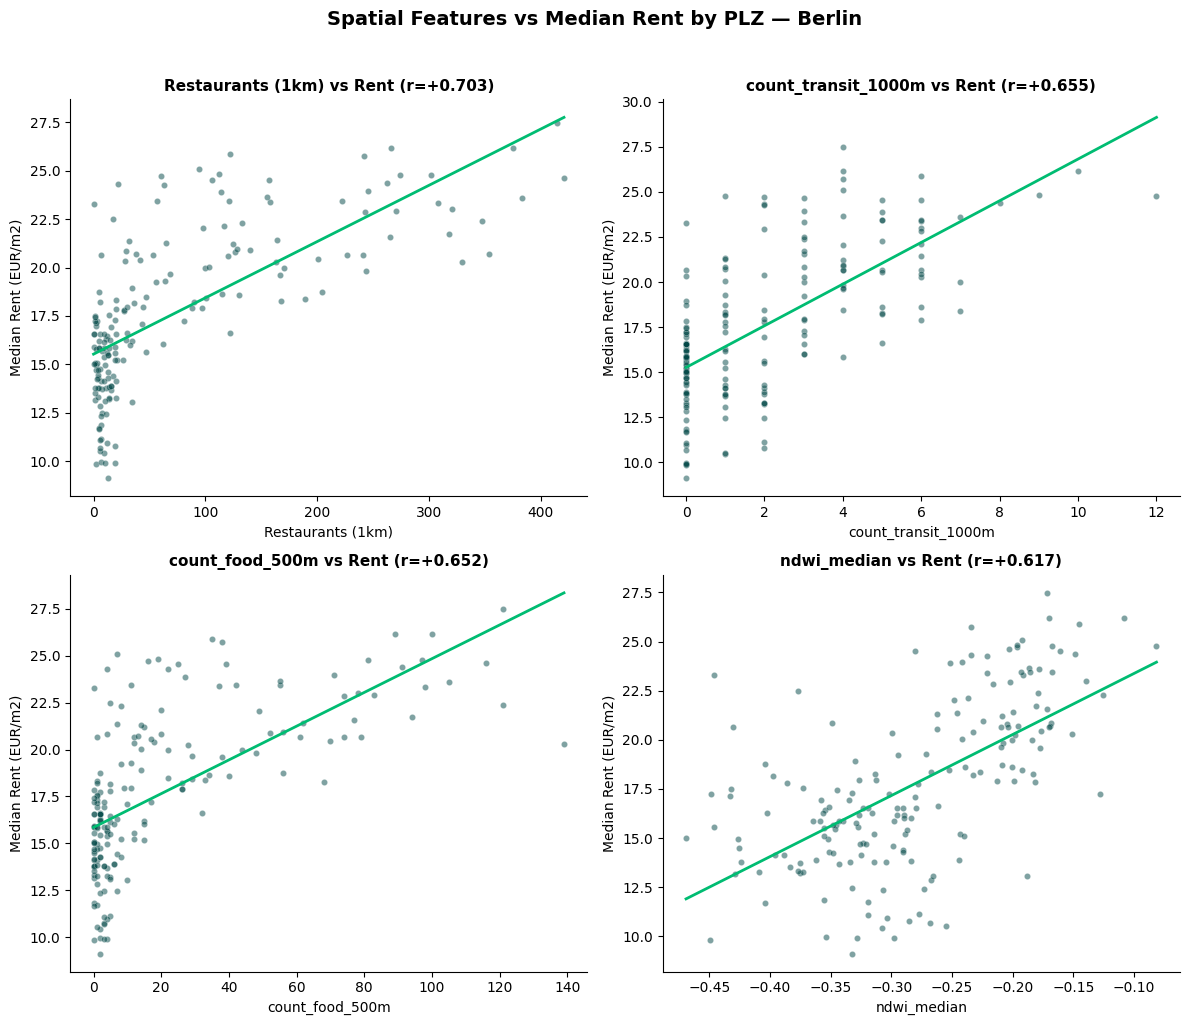


Saved: data/processed/neighborhood_correlations.png


In [4]:
# Correlation between spatial features and median rent
print("Correlation: spatial features vs median rent (2024 adjusted)\n")
spatial_cols = [c for c in plz_intel.columns if c in spatial.columns and c != "plz"]
corrs = plz_intel[spatial_cols + ["rent_median"]].corr()["rent_median"].drop("rent_median").sort_values(ascending=False)

print(f"{'Feature':<25} {'Correlation':>12}")
print("-" * 40)
for feat, corr in corrs.items():
    label = KEY_FEATURES.get(feat, feat)
    print(f"  {label:<23} {corr:>+10.3f}")

# Visualize top correlations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
top_corr_feats = corrs.abs().nlargest(4).index.tolist()

for ax, feat in zip(axes.flat, top_corr_feats):
    label = KEY_FEATURES.get(feat, feat)
    x = plz_intel[feat]
    y = plz_intel["rent_median"]
    valid = x.notna() & y.notna()
    ax.scatter(x[valid], y[valid], alpha=0.5, s=20, color="#004746", edgecolor="white", linewidth=0.3)
    
    # Trend line
    z = np.polyfit(x[valid], y[valid], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x[valid])
    ax.plot(x_sorted, p(x_sorted), color="#00BC72", linewidth=2)
    
    r = corrs[feat]
    ax.set_xlabel(label)
    ax.set_ylabel("Median Rent (EUR/m2)")
    ax.set_title(f"{label} vs Rent (r={r:+.3f})", fontweight="bold", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Spatial Features vs Median Rent by PLZ — Berlin", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/neighborhood_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: data/processed/neighborhood_correlations.png")

## Step 4: Export PLZ Intelligence JSON for API

In [5]:
# Export PLZ intelligence as JSON for the /neighborhood endpoints
export = []
for _, row in plz_intel.iterrows():
    entry = {
        "plz": int(row["plz"]),
        "listing_count": int(row["count"]),
        "rent": {
            "median": row["rent_median"],
            "p25": row["rent_p25"],
            "p75": row["rent_p75"],
            "mean": row["rent_mean"],
        },
        "building_stock": {
            "avg_sqm": round(row["avg_sqm"], 1),
            "avg_year_built": int(row["avg_year"]),
            "pct_with_kitchen": round(row["pct_kitchen"] * 100, 1),
            "pct_with_balcony": round(row["pct_balcony"] * 100, 1),
            "pct_with_elevator": round(row["pct_elevator"] * 100, 1),
        },
        "spatial": {},
    }
    for feat in spatial.columns:
        if feat != "plz" and feat in row.index and pd.notna(row[feat]):
            entry["spatial"][feat] = round(float(row[feat]), 4)
    export.append(entry)

# Save
with open("../data/processed/plz_intelligence.json", "w") as f:
    json.dump(export, f, indent=2)

print(f"Exported {len(export)} PLZs to data/processed/plz_intelligence.json")
print(f"\nSample (PLZ 10997 — Kreuzberg):")
kreuzberg = [e for e in export if e["plz"] == 10997]
if kreuzberg:
    print(json.dumps(kreuzberg[0], indent=2))

Exported 181 PLZs to data/processed/plz_intelligence.json

Sample (PLZ 10997 — Kreuzberg):
{
  "plz": 10997,
  "listing_count": 46,
  "rent": {
    "median": 22.93,
    "p25": 19.99,
    "p75": 27.56,
    "mean": 23.58
  },
  "building_stock": {
    "avg_sqm": 84.4,
    "avg_year_built": 1931,
    "pct_with_kitchen": 63.0,
    "pct_with_balcony": 52.0,
    "pct_with_elevator": 28.0
  },
  "spatial": {
    "dist_transit_m": 413.9187,
    "dist_park_m": 201.4644,
    "dist_water_m": 600.9656,
    "dist_school_m": 29.7662,
    "count_food_500m": 83.0,
    "count_shop_500m": 16.0,
    "count_food_1000m": 271.0,
    "count_shop_1000m": 60.0,
    "count_transit_1000m": 2.0,
    "ndvi_mean": 0.2212,
    "ndvi_std": 0.1396,
    "ndvi_median": 0.1925,
    "ndwi_mean": -0.2219,
    "ndwi_std": 0.1225,
    "ndwi_median": -0.2021,
    "ndbi_mean": -0.032,
    "ndbi_std": 0.1,
    "ndbi_median": -0.0246
  }
}
